# Linear Regression with Ridge & Lasso regularization
House price prediction from `area` and `rooms`.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df = pd.read_csv('data/house_price.csv')
df.describe()

,area,rooms,price
count,500.000000,500.000000,500.000000
mean,1792.996000,2.982000,245997.600000
std,527.387014,1.135012,69905.106839
min,500.000000,1.000000,41200.000000
25%,1433.250000,2.000000,201750.000000
50%,1801.500000,3.000000,247850.000000
75%,2122.750000,4.000000,287650.000000
max,3403.000000,6.000000,465700.000000


In [2]:
X, y = df[['area','rooms']], df['price']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
sc = StandardScaler().fit(X_tr.values)
Xs_tr, Xs_te = sc.transform(X_tr.values), sc.transform(X_te.values)

## Compare models

In [3]:
rows=[]
for name, m in {'Linear':LinearRegression(),'Ridge':Ridge(1.0),'Lasso':Lasso(1.0)}.items():
    m.fit(Xs_tr, y_tr); p = m.predict(Xs_te)
    rows.append([name, mean_absolute_error(y_te,p), np.sqrt(mean_squared_error(y_te,p)), r2_score(y_te,p), cross_val_score(m,Xs_tr,y_tr,cv=5,scoring='r2').mean()])
pd.DataFrame(rows, columns=['model','MAE','RMSE','R2','CV_R2']).round(3)

,model,MAE,RMSE,R2,CV_R2
0,Linear,16143.560,20796.539,0.899,0.894
1,Ridge,16168.013,20789.355,0.900,0.894
2,Lasso,16143.221,20796.575,0.899,0.894


## Effect of the regularization strength (alpha)
Coefficients shrink as alpha grows; Lasso can drive them to zero.

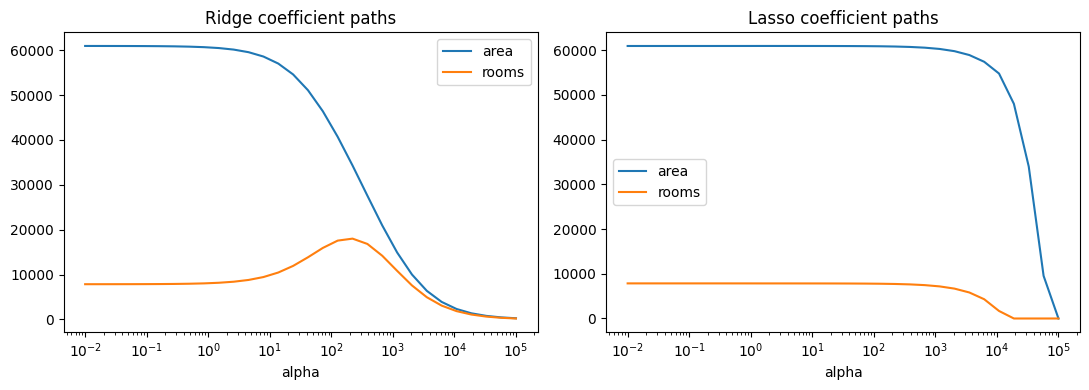

In [4]:
alphas = np.logspace(-2, 5, 30)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a_, cls, t in [(ax[0], Ridge, 'Ridge'), (ax[1], Lasso, 'Lasso')]:
    coefs = [cls(alpha=al).fit(Xs_tr, y_tr).coef_ for al in alphas]
    a_.semilogx(alphas, coefs); a_.set_title(f'{t} coefficient paths'); a_.set_xlabel('alpha'); a_.legend(['area','rooms'])
plt.tight_layout(); plt.show()

## Conclusion
With only two informative features and 400 training rows, regularization changes almost nothing, so plain Linear Regression is deployed.